In [543]:
from IPython.display import HTML
import jupyprint as jp
import numpy as np
from pandas import DataFrame

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 10,
})

from sympy import *

Define variables that we are going to use repetitively:
$s, t, \tau$.

In [544]:
t   = symbols('t', real=True, nonnegative=True)
s   = symbols('s', complex=True)
tau = symbols('tau', real=True)

Simplify:
*  ```laplace_transform(...)``` as ```lapalce(...)```
*  ```inverse_laplace_transform(...)``` as ```ilapalce(...)```

In [545]:
def laplace(f):
    F = laplace_transform(f, t, s, noconds=True)
    return F

def ilaplace(F):
    f = inverse_laplace_transform(F, s, t)
    return f

## First-order system equation

In [546]:
print("Given a first order system:")
G = 1 / (tau*s + 1)
jp.jupyprint('$G(s)=\\frac{C(s)}{R(s)}=' + latex(G)+'$')

Given a first order system:


$G(s)=\frac{C(s)}{R(s)}=\frac{1}{s \tau + 1}$

### Unit-impulse response

In [547]:
print("Unit-impulse input:")

r = DiracDelta(t)
jp.jupyprint("$r(t)="+latex(r)+"$")

R = laplace(r)
jp.jupyprint("$R(s)="+latex(R)+"$")

C = G*R
jp.jupyprint('$C(s)=' + latex(C) + '$')

c = collect(ilaplace(C), Heaviside(t))
jp.jupyprint('$c(t)=' + latex(c) + '$')

Unit-impulse input:


$r(t)=\delta\left(t\right)$

$R(s)=1$

$C(s)=\frac{1}{s \tau + 1}$

$c(t)=\frac{e^{- \frac{t}{\tau}} \theta\left(t\right)}{\tau}$

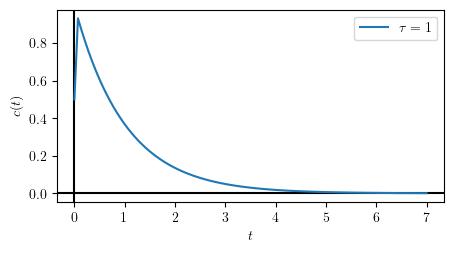

In [548]:
%matplotlib inline
fig = plt.figure(figsize=(5,2.5))
ax = fig.add_subplot()
ax.axvline(x=0, c="k")
ax.axhline(y=0, c="k")

T = np.linspace(0, 7, 100)
tau_ = 1

Y = T * 0.0
for k, t_ in enumerate(T):
    Y[k] = c.subs([(tau, tau_),(t, t_)])

label = '$\\tau='+str(tau_)+'$'
ax.plot(T,Y, label=label)

ax.set_xlabel('$t$');
ax.set_ylabel('$c(t)$');
ax.legend();


### Unit-step response

In [549]:
print("Unit-step input:")

r = Heaviside(t)
jp.jupyprint("$r(t)="+latex(r)+"$")

R = laplace(r)
jp.jupyprint("$R(s)="+latex(R)+"$")

C = G*R
jp.jupyprint('$C(s)=' + latex(C) + '$')

c = collect(ilaplace(C), Heaviside(t))
jp.jupyprint('$c(t)=' + latex(c) + '$')

Unit-step input:


$r(t)=\theta\left(t\right)$

$R(s)=\frac{1}{s}$

$C(s)=\frac{1}{s \left(s \tau + 1\right)}$

$c(t)=\left(1 - e^{- \frac{t}{\tau}}\right) \theta\left(t\right)$

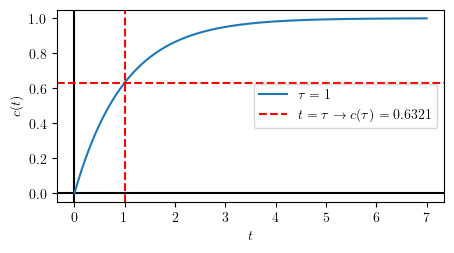

In [550]:
%matplotlib inline
fig = plt.figure(figsize=(5,2.5))
ax = fig.add_subplot()
ax.axvline(x=0, c="k")
ax.axhline(y=0, c="k")

T = np.linspace(0, 7, 100)
tau_ = 1

Y = T * 0.0
for k, t_ in enumerate(T):
    Y[k] = c.subs([(tau, tau_),(t, t_)])

label = '$\\tau='+str(tau_)+'$'
ax.plot(T,Y, label=label)

ctau = c.subs([(tau, tau_),(t, 1)])

ax.axvline(x=tau_, color='r', linestyle='--', label=f'$t=\\tau \\rightarrow c(\\tau) = {ctau:.4f}$')
ax.axhline(y=ctau, color='r', linestyle='--')

ax.set_xlabel('$t$');
ax.set_ylabel('$c(t)$');
ax.legend();


The figure above shows that at $t = \tau$, $c(\tau)$ is at $63.21 \%$ of $c_{ss}$

### Unit-ramp response

In [551]:
print("Unit-ramp input:")

r = t
jp.jupyprint("$r(t)="+latex(r)+"$")

R = laplace(r)
jp.jupyprint("$R(s)="+latex(R)+"$")

C = G*R
jp.jupyprint('$C(s)=' + latex(C) + '$')

c = collect(ilaplace(C), Heaviside(t))
jp.jupyprint('$c(t)=' + latex(c) + '$')

Unit-ramp input:


$r(t)=t$

$R(s)=\frac{1}{s^{2}}$

$C(s)=\frac{1}{s^{2} \left(s \tau + 1\right)}$

$c(t)=\left(t - \tau + \tau e^{- \frac{t}{\tau}}\right) \theta\left(t\right)$

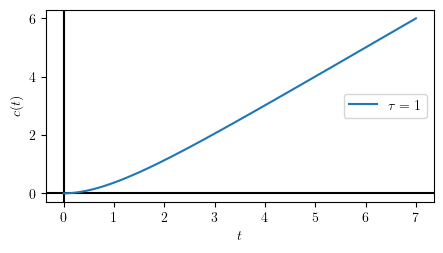

In [552]:
%matplotlib inline
fig = plt.figure(figsize=(5,2.5))
ax = fig.add_subplot()

ax.axvline(x=0, c="k")
ax.axhline(y=0, c="k")

T = np.linspace(0, 7, 100)
tau_ = 1

Y = T * 0.0
for k, t_ in enumerate(T):
    Y[k] = c.subs([(tau, tau_),(t, t_)])

label = '$\\tau='+str(tau_)+'$'
ax.plot(T,Y, label=label)

ax.set_xlabel('$t$');
ax.set_ylabel('$c(t)$');
ax.legend();


## Final Value Theorem

The steady state value for each input can be found by using final value theorem: 

$$\boxed{c_{ss} = \lim _{t \rightarrow \infty} c(t)=\lim _{s \rightarrow 0} s C(s)}$$

### Unit-impulse

In [553]:
r = DiracDelta(t)
css = limit(s*G*laplace(r), s, 0)

jp.jupyprint('$r(t)=' + latex(r) + '\\rightarrow c_{ss}=' + latex(css) + '$')

$r(t)=\delta\left(t\right)\rightarrow c_{ss}=0$

### Unit-step

In [554]:
r = Heaviside(t)
css = limit(s*G*laplace(r), s, 0)

jp.jupyprint('$r(t)=' + latex(r) + '\\rightarrow c_{ss}=' + latex(css) + '$')

$r(t)=\theta\left(t\right)\rightarrow c_{ss}=1$

### Unit-ramp

In [555]:
r = t
css = limit(s*G*laplace(r), s, 0)

jp.jupyprint('$r(t)=' + latex(r) + '\\rightarrow c_{ss}=' + latex(css) + '$')

$r(t)=t\rightarrow c_{ss}=\infty$